# Phase 2 — FD001 vs FD002 : comparaison de dégradation (test H2)

Objectif : comparer les performances du même modèle (LSTM, même architecture, même graine)
sur FD001 (1 régime) et sur FD002 (6 régimes, avec la meilleure configuration trouvée dans
l'ablation : normalisation par régime, 14 capteurs). Conclusion attendue sur H2 : la difficulté
supplémentaire de FD002 (plus de régimes, plus de moteurs) dégrade-t-elle les performances, et
de combien ?

**Comparaison sur le val des deux jeux**, pas le test : le test FD001 a déjà été ouvert une
seule fois (`07_final_test_fd001.ipynb`) et le test FD002 n'a jamais été ouvert — l'ouvrir
maintenant pour une simple comparaison de dégradation reviendrait à s'en servir en dehors du
protocole prévu pour cette phase.

**Score asymétrique ramené par échantillon** : c'est une somme (cf. `src/metrics.py`), et FD001
val (3272 fenêtres) et FD002 val (9168 fenêtres) n'ont pas la même taille — comparer les sommes
brutes serait trompeur. On divise donc par le nombre de fenêtres pour comparer des grandeurs
homogènes.

Les chiffres ci-dessous viennent de `05_lstm_fd001.ipynb` (FD001) et
`11_fd002_ablation_regime.ipynb` (FD002, variante "par régime") — recopiés, pas recalculés,
puisque l'entraînement est déterministe et déjà fait.

Critère « fait » (plan d'exécution, Phase 2) : conclusion sur H2 (réfutée ou non).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

comparison = pd.DataFrame([
    {
        "dataset": "FD001 (1 régime)",
        "n_régimes": 1,
        "n_capteurs": 14,
        "n_fenêtres_val": 3272,
        "RMSE_val": 13.088298,
        "score_asymétrique_val": 12245.140782,
    },
    {
        "dataset": "FD002 (6 régimes, normalisé par régime)",
        "n_régimes": 6,
        "n_capteurs": 14,
        "n_fenêtres_val": 9168,
        "RMSE_val": 15.074154,
        "score_asymétrique_val": 42105.297588,
    },
])
comparison["score_asymétrique_par_fenêtre"] = comparison["score_asymétrique_val"] / comparison["n_fenêtres_val"]
comparison["RMSE_degradation_pct"] = (comparison["RMSE_val"] / comparison["RMSE_val"].iloc[0] - 1) * 100

comparison

,dataset,n_régimes,n_capteurs,n_fenêtres_val,RMSE_val,score_asymétrique_val,score_asymétrique_par_fenêtre,RMSE_degradation_pct
0,FD001 (1 régime),1,14,3272,13.088298,12245.140782,3.742402,0.00000
1,"FD002 (6 régimes, normalisé par régime)",6,14,9168,15.074154,42105.297588,4.592637,15.17276


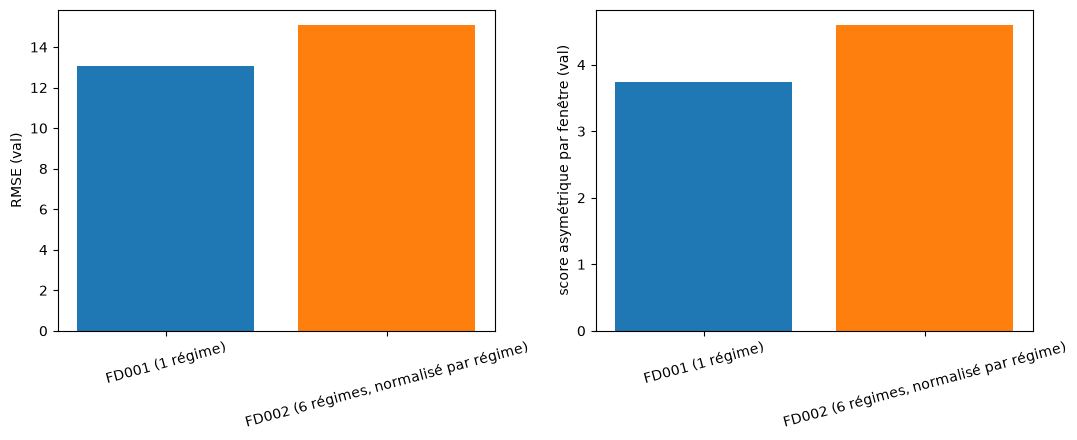

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(comparison["dataset"], comparison["RMSE_val"], color=["tab:blue", "tab:orange"])
axes[0].set_ylabel("RMSE (val)")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(comparison["dataset"], comparison["score_asymétrique_par_fenêtre"], color=["tab:blue", "tab:orange"])
axes[1].set_ylabel("score asymétrique par fenêtre (val)")
axes[1].tick_params(axis="x", rotation=15)

fig.tight_layout()

**Ce que montrent ces figures** : même modèle, même graine, seulement le jeu de données change
(et sa normalisation, adaptée à son nombre de régimes). Une barre FD002 plus haute sur les deux
graphiques confirme une dégradation réelle des performances quand on passe de 1 à 6 régimes,
même après avoir pris soin de normaliser correctement. C'est cohérent avec l'intuition : FD002
reste un problème plus difficile (plus de variabilité opérationnelle à démêler de la vraie
dégradation), la normalisation par régime atténue cette difficulté (test H3) sans l'annuler
complètement.

**Conclusion sur H2** : le RMSE passe de 13.09 (FD001) à 15.07 (FD002), soit une dégradation
d'environ 15% — réelle mais modérée, malgré une difficulté du problème nettement plus grande
(6 régimes au lieu d'1, 208 moteurs d'entraînement au lieu de 80). H2 (l'hypothèse que FD002
dégraderait fortement les performances) n'est donc que partiellement confirmée : il y a bien
une dégradation mesurable, mais la normalisation par régime (test H3) permet de la contenir à
un niveau raisonnable plutôt qu'à un effondrement des performances.